# Credit Risk EDA + USREC Recession History

Two independent analyses — no join is attempted.
The Kaggle dataset has no date column so merging with a time series is not valid.

- **Part 1:** EDA on the Kaggle Credit Risk Dataset
- **Part 2:** EDA on USREC recession history (1950-2024, hardcoded from FRED)

Sources:
- https://www.kaggle.com/datasets/laotse/credit-risk-dataset
- https://fred.stlouisfed.org/series/USREC

## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

## Part 1: Credit Risk Dataset
### 2. Load & Clean

In [17]:
# Download from: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

import kagglehub
import os

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Available files:", files)

csv_file = os.path.join(path, files[0])
credit = pd.read_csv(csv_file)
credit = credit[credit['person_age'] < 100].copy()
credit['loan_int_rate']     = credit['loan_int_rate'].fillna(credit['loan_int_rate'].median())
credit['person_emp_length'] = credit['person_emp_length'].fillna(credit['person_emp_length'].median())
credit['loan_grade']        = credit['loan_grade'].str.upper()
credit['loan_intent']       = credit['loan_intent'].str.upper()
print(f'Rows: {len(credit):,}  |  Default rate: {credit["loan_status"].mean():.2%}')
credit.head()

Dataset downloaded to: /Users/rajevasan/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1
Available files: ['credit_risk_dataset.csv']
Rows: 32,576  |  Default rate: 21.82%


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 3. Credit EDA

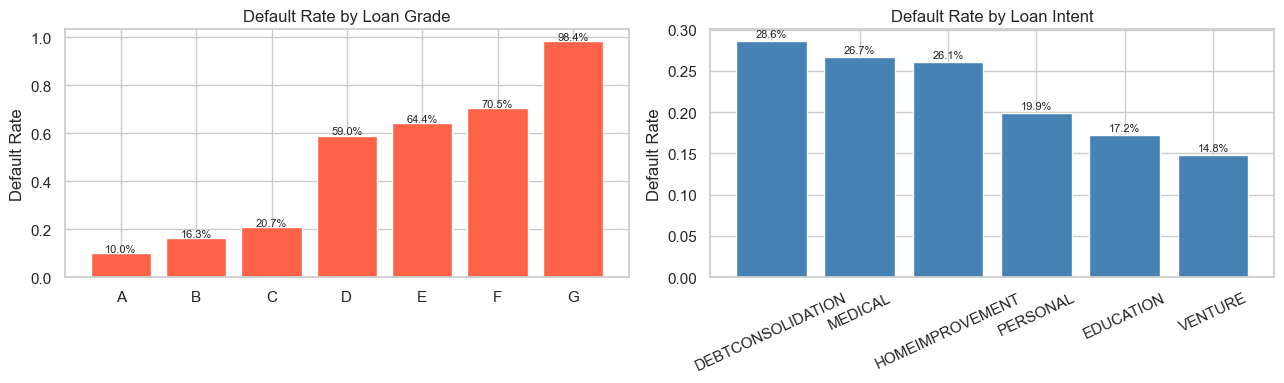

In [18]:
# Default rate by loan grade and intent
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

grade_order = sorted(credit['loan_grade'].dropna().unique())
default_by_grade = credit.groupby('loan_grade')['loan_status'].mean().reindex(grade_order)
bars = axes[0].bar(grade_order, default_by_grade.values, color='tomato', edgecolor='white')
axes[0].set_title('Default Rate by Loan Grade')
axes[0].set_ylabel('Default Rate')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', fontsize=8)

default_by_intent = credit.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(default_by_intent.index, default_by_intent.values, color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Loan Intent')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=25)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

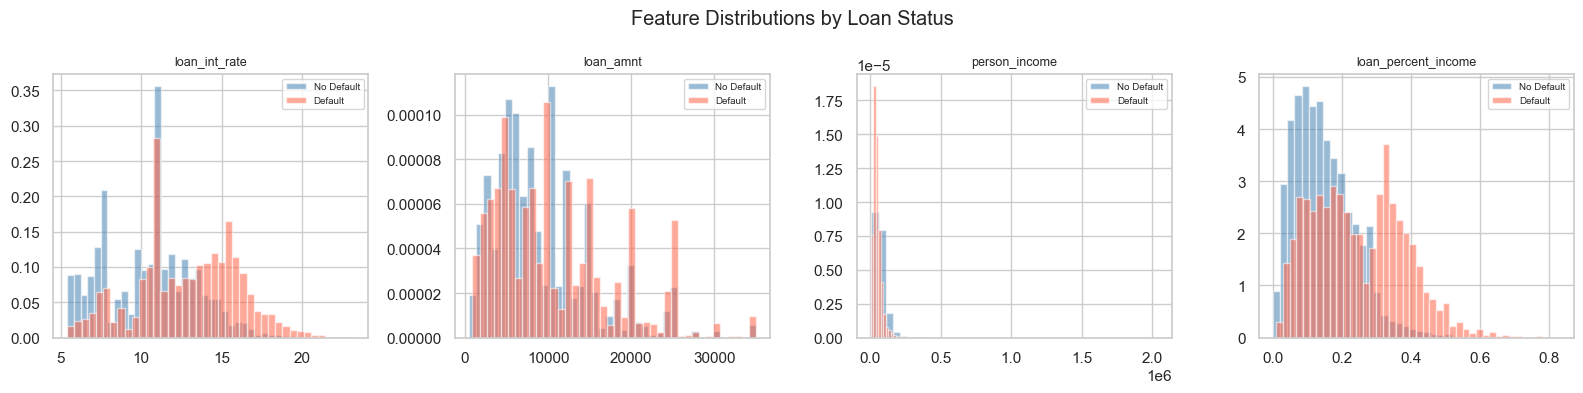

In [19]:
# Numeric distributions by default status
num_cols = ['loan_int_rate', 'loan_amnt', 'person_income', 'loan_percent_income']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(num_cols):
    for status, color, label in [(0, 'steelblue', 'No Default'), (1, 'tomato', 'Default')]:
        axes[i].hist(credit[credit['loan_status'] == status][col].dropna(),
                     bins=40, alpha=0.55, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle('Feature Distributions by Loan Status')
plt.tight_layout()
plt.show()

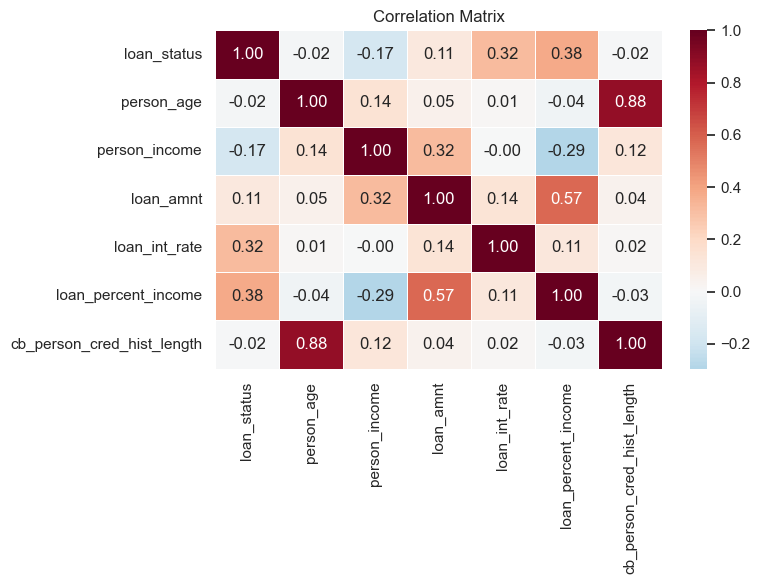

In [20]:
# Correlation heatmap
cols = ['loan_status', 'person_age', 'person_income', 'loan_amnt',
        'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(credit[cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
## Part 2: USREC Recession History
### 4. Load USREC
Hardcoded from FRED (1950-2024). Source: https://fred.stlouisfed.org/series/USREC  
**1 = recession** (NBER peak to trough), **0 = expansion**

In [21]:
USREC_CSV = """DATE,USREC
1950-01-01,0
1950-02-01,0
1950-03-01,0
1950-04-01,0
1950-05-01,0
1950-06-01,0
1950-07-01,0
1950-08-01,0
1950-09-01,0
1950-10-01,0
1950-11-01,0
1950-12-01,0
1951-01-01,0
1951-02-01,0
1951-03-01,0
1951-04-01,0
1951-05-01,0
1951-06-01,0
1951-07-01,0
1951-08-01,0
1951-09-01,0
1951-10-01,0
1951-11-01,0
1951-12-01,0
1952-01-01,0
1952-02-01,0
1952-03-01,0
1952-04-01,0
1952-05-01,0
1952-06-01,0
1952-07-01,0
1952-08-01,0
1952-09-01,0
1952-10-01,0
1952-11-01,0
1952-12-01,0
1953-01-01,0
1953-02-01,0
1953-03-01,0
1953-04-01,0
1953-05-01,0
1953-06-01,0
1953-07-01,0
1953-08-01,1
1953-09-01,1
1953-10-01,1
1953-11-01,1
1953-12-01,1
1954-01-01,1
1954-02-01,1
1954-03-01,1
1954-04-01,1
1954-05-01,1
1954-06-01,0
1954-07-01,0
1954-08-01,0
1954-09-01,0
1954-10-01,0
1954-11-01,0
1954-12-01,0
1955-01-01,0
1955-02-01,0
1955-03-01,0
1955-04-01,0
1955-05-01,0
1955-06-01,0
1955-07-01,0
1955-08-01,0
1955-09-01,0
1955-10-01,0
1955-11-01,0
1955-12-01,0
1956-01-01,0
1956-02-01,0
1956-03-01,0
1956-04-01,0
1956-05-01,0
1956-06-01,0
1956-07-01,0
1956-08-01,0
1956-09-01,0
1956-10-01,0
1956-11-01,0
1956-12-01,0
1957-01-01,0
1957-02-01,0
1957-03-01,0
1957-04-01,0
1957-05-01,0
1957-06-01,0
1957-07-01,0
1957-08-01,0
1957-09-01,1
1957-10-01,1
1957-11-01,1
1957-12-01,1
1958-01-01,1
1958-02-01,1
1958-03-01,1
1958-04-01,1
1958-05-01,0
1958-06-01,0
1958-07-01,0
1958-08-01,0
1958-09-01,0
1958-10-01,0
1958-11-01,0
1958-12-01,0
1959-01-01,0
1959-02-01,0
1959-03-01,0
1959-04-01,0
1959-05-01,0
1959-06-01,0
1959-07-01,0
1959-08-01,0
1959-09-01,0
1959-10-01,0
1959-11-01,0
1959-12-01,0
1960-01-01,0
1960-02-01,0
1960-03-01,0
1960-04-01,0
1960-05-01,1
1960-06-01,1
1960-07-01,1
1960-08-01,1
1960-09-01,1
1960-10-01,1
1960-11-01,1
1960-12-01,1
1961-01-01,1
1961-02-01,1
1961-03-01,0
1961-04-01,0
1961-05-01,0
1961-06-01,0
1961-07-01,0
1961-08-01,0
1961-09-01,0
1961-10-01,0
1961-11-01,0
1961-12-01,0
1962-01-01,0
1962-02-01,0
1962-03-01,0
1962-04-01,0
1962-05-01,0
1962-06-01,0
1962-07-01,0
1962-08-01,0
1962-09-01,0
1962-10-01,0
1962-11-01,0
1962-12-01,0
1963-01-01,0
1963-02-01,0
1963-03-01,0
1963-04-01,0
1963-05-01,0
1963-06-01,0
1963-07-01,0
1963-08-01,0
1963-09-01,0
1963-10-01,0
1963-11-01,0
1963-12-01,0
1964-01-01,0
1964-02-01,0
1964-03-01,0
1964-04-01,0
1964-05-01,0
1964-06-01,0
1964-07-01,0
1964-08-01,0
1964-09-01,0
1964-10-01,0
1964-11-01,0
1964-12-01,0
1965-01-01,0
1965-02-01,0
1965-03-01,0
1965-04-01,0
1965-05-01,0
1965-06-01,0
1965-07-01,0
1965-08-01,0
1965-09-01,0
1965-10-01,0
1965-11-01,0
1965-12-01,0
1966-01-01,0
1966-02-01,0
1966-03-01,0
1966-04-01,0
1966-05-01,0
1966-06-01,0
1966-07-01,0
1966-08-01,0
1966-09-01,0
1966-10-01,0
1966-11-01,0
1966-12-01,0
1967-01-01,0
1967-02-01,0
1967-03-01,0
1967-04-01,0
1967-05-01,0
1967-06-01,0
1967-07-01,0
1967-08-01,0
1967-09-01,0
1967-10-01,0
1967-11-01,0
1967-12-01,0
1968-01-01,0
1968-02-01,0
1968-03-01,0
1968-04-01,0
1968-05-01,0
1968-06-01,0
1968-07-01,0
1968-08-01,0
1968-09-01,0
1968-10-01,0
1968-11-01,0
1968-12-01,0
1969-01-01,0
1969-02-01,0
1969-03-01,0
1969-04-01,0
1969-05-01,0
1969-06-01,0
1969-07-01,0
1969-08-01,0
1969-09-01,0
1969-10-01,0
1969-11-01,0
1969-12-01,0
1970-01-01,1
1970-02-01,1
1970-03-01,1
1970-04-01,1
1970-05-01,1
1970-06-01,1
1970-07-01,1
1970-08-01,1
1970-09-01,1
1970-10-01,1
1970-11-01,1
1970-12-01,0
1971-01-01,0
1971-02-01,0
1971-03-01,0
1971-04-01,0
1971-05-01,0
1971-06-01,0
1971-07-01,0
1971-08-01,0
1971-09-01,0
1971-10-01,0
1971-11-01,0
1971-12-01,0
1972-01-01,0
1972-02-01,0
1972-03-01,0
1972-04-01,0
1972-05-01,0
1972-06-01,0
1972-07-01,0
1972-08-01,0
1972-09-01,0
1972-10-01,0
1972-11-01,0
1972-12-01,0
1973-01-01,0
1973-02-01,0
1973-03-01,0
1973-04-01,0
1973-05-01,0
1973-06-01,0
1973-07-01,0
1973-08-01,0
1973-09-01,0
1973-10-01,0
1973-11-01,0
1973-12-01,1
1974-01-01,1
1974-02-01,1
1974-03-01,1
1974-04-01,1
1974-05-01,1
1974-06-01,1
1974-07-01,1
1974-08-01,1
1974-09-01,1
1974-10-01,1
1974-11-01,1
1974-12-01,1
1975-01-01,1
1975-02-01,1
1975-03-01,1
1975-04-01,0
1975-05-01,0
1975-06-01,0
1975-07-01,0
1975-08-01,0
1975-09-01,0
1975-10-01,0
1975-11-01,0
1975-12-01,0
1976-01-01,0
1976-02-01,0
1976-03-01,0
1976-04-01,0
1976-05-01,0
1976-06-01,0
1976-07-01,0
1976-08-01,0
1976-09-01,0
1976-10-01,0
1976-11-01,0
1976-12-01,0
1977-01-01,0
1977-02-01,0
1977-03-01,0
1977-04-01,0
1977-05-01,0
1977-06-01,0
1977-07-01,0
1977-08-01,0
1977-09-01,0
1977-10-01,0
1977-11-01,0
1977-12-01,0
1978-01-01,0
1978-02-01,0
1978-03-01,0
1978-04-01,0
1978-05-01,0
1978-06-01,0
1978-07-01,0
1978-08-01,0
1978-09-01,0
1978-10-01,0
1978-11-01,0
1978-12-01,0
1979-01-01,0
1979-02-01,0
1979-03-01,0
1979-04-01,0
1979-05-01,0
1979-06-01,0
1979-07-01,0
1979-08-01,0
1979-09-01,0
1979-10-01,0
1979-11-01,0
1979-12-01,0
1980-01-01,0
1980-02-01,1
1980-03-01,1
1980-04-01,1
1980-05-01,1
1980-06-01,1
1980-07-01,1
1980-08-01,0
1980-09-01,0
1980-10-01,0
1980-11-01,0
1980-12-01,0
1981-01-01,0
1981-02-01,0
1981-03-01,0
1981-04-01,0
1981-05-01,0
1981-06-01,0
1981-07-01,0
1981-08-01,1
1981-09-01,1
1981-10-01,1
1981-11-01,1
1981-12-01,1
1982-01-01,1
1982-02-01,1
1982-03-01,1
1982-04-01,1
1982-05-01,1
1982-06-01,1
1982-07-01,1
1982-08-01,1
1982-09-01,1
1982-10-01,1
1982-11-01,1
1982-12-01,0
1983-01-01,0
1983-02-01,0
1983-03-01,0
1983-04-01,0
1983-05-01,0
1983-06-01,0
1983-07-01,0
1983-08-01,0
1983-09-01,0
1983-10-01,0
1983-11-01,0
1983-12-01,0
1984-01-01,0
1984-02-01,0
1984-03-01,0
1984-04-01,0
1984-05-01,0
1984-06-01,0
1984-07-01,0
1984-08-01,0
1984-09-01,0
1984-10-01,0
1984-11-01,0
1984-12-01,0
1985-01-01,0
1985-02-01,0
1985-03-01,0
1985-04-01,0
1985-05-01,0
1985-06-01,0
1985-07-01,0
1985-08-01,0
1985-09-01,0
1985-10-01,0
1985-11-01,0
1985-12-01,0
1986-01-01,0
1986-02-01,0
1986-03-01,0
1986-04-01,0
1986-05-01,0
1986-06-01,0
1986-07-01,0
1986-08-01,0
1986-09-01,0
1986-10-01,0
1986-11-01,0
1986-12-01,0
1987-01-01,0
1987-02-01,0
1987-03-01,0
1987-04-01,0
1987-05-01,0
1987-06-01,0
1987-07-01,0
1987-08-01,0
1987-09-01,0
1987-10-01,0
1987-11-01,0
1987-12-01,0
1988-01-01,0
1988-02-01,0
1988-03-01,0
1988-04-01,0
1988-05-01,0
1988-06-01,0
1988-07-01,0
1988-08-01,0
1988-09-01,0
1988-10-01,0
1988-11-01,0
1988-12-01,0
1989-01-01,0
1989-02-01,0
1989-03-01,0
1989-04-01,0
1989-05-01,0
1989-06-01,0
1989-07-01,0
1989-08-01,0
1989-09-01,0
1989-10-01,0
1989-11-01,0
1989-12-01,0
1990-01-01,0
1990-02-01,0
1990-03-01,0
1990-04-01,0
1990-05-01,0
1990-06-01,0
1990-07-01,0
1990-08-01,1
1990-09-01,1
1990-10-01,1
1990-11-01,1
1990-12-01,1
1991-01-01,1
1991-02-01,1
1991-03-01,1
1991-04-01,0
1991-05-01,0
1991-06-01,0
1991-07-01,0
1991-08-01,0
1991-09-01,0
1991-10-01,0
1991-11-01,0
1991-12-01,0
1992-01-01,0
1992-02-01,0
1992-03-01,0
1992-04-01,0
1992-05-01,0
1992-06-01,0
1992-07-01,0
1992-08-01,0
1992-09-01,0
1992-10-01,0
1992-11-01,0
1992-12-01,0
1993-01-01,0
1993-02-01,0
1993-03-01,0
1993-04-01,0
1993-05-01,0
1993-06-01,0
1993-07-01,0
1993-08-01,0
1993-09-01,0
1993-10-01,0
1993-11-01,0
1993-12-01,0
1994-01-01,0
1994-02-01,0
1994-03-01,0
1994-04-01,0
1994-05-01,0
1994-06-01,0
1994-07-01,0
1994-08-01,0
1994-09-01,0
1994-10-01,0
1994-11-01,0
1994-12-01,0
1995-01-01,0
1995-02-01,0
1995-03-01,0
1995-04-01,0
1995-05-01,0
1995-06-01,0
1995-07-01,0
1995-08-01,0
1995-09-01,0
1995-10-01,0
1995-11-01,0
1995-12-01,0
1996-01-01,0
1996-02-01,0
1996-03-01,0
1996-04-01,0
1996-05-01,0
1996-06-01,0
1996-07-01,0
1996-08-01,0
1996-09-01,0
1996-10-01,0
1996-11-01,0
1996-12-01,0
1997-01-01,0
1997-02-01,0
1997-03-01,0
1997-04-01,0
1997-05-01,0
1997-06-01,0
1997-07-01,0
1997-08-01,0
1997-09-01,0
1997-10-01,0
1997-11-01,0
1997-12-01,0
1998-01-01,0
1998-02-01,0
1998-03-01,0
1998-04-01,0
1998-05-01,0
1998-06-01,0
1998-07-01,0
1998-08-01,0
1998-09-01,0
1998-10-01,0
1998-11-01,0
1998-12-01,0
1999-01-01,0
1999-02-01,0
1999-03-01,0
1999-04-01,0
1999-05-01,0
1999-06-01,0
1999-07-01,0
1999-08-01,0
1999-09-01,0
1999-10-01,0
1999-11-01,0
1999-12-01,0
2000-01-01,0
2000-02-01,0
2000-03-01,0
2000-04-01,0
2000-05-01,0
2000-06-01,0
2000-07-01,0
2000-08-01,0
2000-09-01,0
2000-10-01,0
2000-11-01,0
2000-12-01,0
2001-01-01,0
2001-02-01,0
2001-03-01,0
2001-04-01,1
2001-05-01,1
2001-06-01,1
2001-07-01,1
2001-08-01,1
2001-09-01,1
2001-10-01,1
2001-11-01,1
2001-12-01,0
2002-01-01,0
2002-02-01,0
2002-03-01,0
2002-04-01,0
2002-05-01,0
2002-06-01,0
2002-07-01,0
2002-08-01,0
2002-09-01,0
2002-10-01,0
2002-11-01,0
2002-12-01,0
2003-01-01,0
2003-02-01,0
2003-03-01,0
2003-04-01,0
2003-05-01,0
2003-06-01,0
2003-07-01,0
2003-08-01,0
2003-09-01,0
2003-10-01,0
2003-11-01,0
2003-12-01,0
2004-01-01,0
2004-02-01,0
2004-03-01,0
2004-04-01,0
2004-05-01,0
2004-06-01,0
2004-07-01,0
2004-08-01,0
2004-09-01,0
2004-10-01,0
2004-11-01,0
2004-12-01,0
2005-01-01,0
2005-02-01,0
2005-03-01,0
2005-04-01,0
2005-05-01,0
2005-06-01,0
2005-07-01,0
2005-08-01,0
2005-09-01,0
2005-10-01,0
2005-11-01,0
2005-12-01,0
2006-01-01,0
2006-02-01,0
2006-03-01,0
2006-04-01,0
2006-05-01,0
2006-06-01,0
2006-07-01,0
2006-08-01,0
2006-09-01,0
2006-10-01,0
2006-11-01,0
2006-12-01,0
2007-01-01,0
2007-02-01,0
2007-03-01,0
2007-04-01,0
2007-05-01,0
2007-06-01,0
2007-07-01,0
2007-08-01,0
2007-09-01,0
2007-10-01,0
2007-11-01,0
2007-12-01,0
2008-01-01,1
2008-02-01,1
2008-03-01,1
2008-04-01,1
2008-05-01,1
2008-06-01,1
2008-07-01,1
2008-08-01,1
2008-09-01,1
2008-10-01,1
2008-11-01,1
2008-12-01,1
2009-01-01,1
2009-02-01,1
2009-03-01,1
2009-04-01,1
2009-05-01,1
2009-06-01,1
2009-07-01,0
2009-08-01,0
2009-09-01,0
2009-10-01,0
2009-11-01,0
2009-12-01,0
2010-01-01,0
2010-02-01,0
2010-03-01,0
2010-04-01,0
2010-05-01,0
2010-06-01,0
2010-07-01,0
2010-08-01,0
2010-09-01,0
2010-10-01,0
2010-11-01,0
2010-12-01,0
2011-01-01,0
2011-02-01,0
2011-03-01,0
2011-04-01,0
2011-05-01,0
2011-06-01,0
2011-07-01,0
2011-08-01,0
2011-09-01,0
2011-10-01,0
2011-11-01,0
2011-12-01,0
2012-01-01,0
2012-02-01,0
2012-03-01,0
2012-04-01,0
2012-05-01,0
2012-06-01,0
2012-07-01,0
2012-08-01,0
2012-09-01,0
2012-10-01,0
2012-11-01,0
2012-12-01,0
2013-01-01,0
2013-02-01,0
2013-03-01,0
2013-04-01,0
2013-05-01,0
2013-06-01,0
2013-07-01,0
2013-08-01,0
2013-09-01,0
2013-10-01,0
2013-11-01,0
2013-12-01,0
2014-01-01,0
2014-02-01,0
2014-03-01,0
2014-04-01,0
2014-05-01,0
2014-06-01,0
2014-07-01,0
2014-08-01,0
2014-09-01,0
2014-10-01,0
2014-11-01,0
2014-12-01,0
2015-01-01,0
2015-02-01,0
2015-03-01,0
2015-04-01,0
2015-05-01,0
2015-06-01,0
2015-07-01,0
2015-08-01,0
2015-09-01,0
2015-10-01,0
2015-11-01,0
2015-12-01,0
2016-01-01,0
2016-02-01,0
2016-03-01,0
2016-04-01,0
2016-05-01,0
2016-06-01,0
2016-07-01,0
2016-08-01,0
2016-09-01,0
2016-10-01,0
2016-11-01,0
2016-12-01,0
2017-01-01,0
2017-02-01,0
2017-03-01,0
2017-04-01,0
2017-05-01,0
2017-06-01,0
2017-07-01,0
2017-08-01,0
2017-09-01,0
2017-10-01,0
2017-11-01,0
2017-12-01,0
2018-01-01,0
2018-02-01,0
2018-03-01,0
2018-04-01,0
2018-05-01,0
2018-06-01,0
2018-07-01,0
2018-08-01,0
2018-09-01,0
2018-10-01,0
2018-11-01,0
2018-12-01,0
2019-01-01,0
2019-02-01,0
2019-03-01,0
2019-04-01,0
2019-05-01,0
2019-06-01,0
2019-07-01,0
2019-08-01,0
2019-09-01,0
2019-10-01,0
2019-11-01,0
2019-12-01,0
2020-01-01,0
2020-02-01,0
2020-03-01,1
2020-04-01,1
2020-05-01,0
2020-06-01,0
2020-07-01,0
2020-08-01,0
2020-09-01,0
2020-10-01,0
2020-11-01,0
2020-12-01,0
2021-01-01,0
2021-02-01,0
2021-03-01,0
2021-04-01,0
2021-05-01,0
2021-06-01,0
2021-07-01,0
2021-08-01,0
2021-09-01,0
2021-10-01,0
2021-11-01,0
2021-12-01,0
2022-01-01,0
2022-02-01,0
2022-03-01,0
2022-04-01,0
2022-05-01,0
2022-06-01,0
2022-07-01,0
2022-08-01,0
2022-09-01,0
2022-10-01,0
2022-11-01,0
2022-12-01,0
2023-01-01,0
2023-02-01,0
2023-03-01,0
2023-04-01,0
2023-05-01,0
2023-06-01,0
2023-07-01,0
2023-08-01,0
2023-09-01,0
2023-10-01,0
2023-11-01,0
2023-12-01,0
2024-01-01,0
2024-02-01,0
2024-03-01,0
2024-04-01,0
2024-05-01,0
2024-06-01,0
2024-07-01,0
2024-08-01,0
2024-09-01,0
2024-10-01,0
2024-11-01,0
2024-12-01,0"""

usrec = pd.read_csv(io.StringIO(USREC_CSV), parse_dates=['DATE'])
usrec.columns = ['date', 'USREC']
usrec['year'] = usrec['date'].dt.year
print(f'Rows: {len(usrec)}  |  Recession months: {usrec["USREC"].sum()}')
usrec.tail(3)

Rows: 900  |  Recession months: 113


,date,USREC,year
897,2024-10-01,0,2024
898,2024-11-01,0,2024
899,2024-12-01,0,2024


### 5. USREC EDA

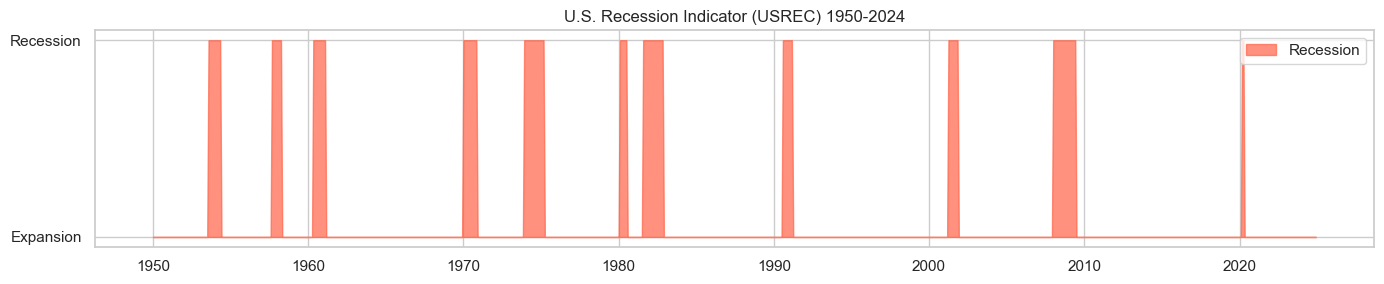

In [22]:
# Recession timeline
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(usrec['date'], usrec['USREC'], color='tomato', alpha=0.7, label='Recession')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Expansion', 'Recession'])
ax.set_title('U.S. Recession Indicator (USREC) 1950-2024')
ax.legend()
plt.tight_layout()
plt.show()

The chart shows the U.S. recession periods from 1950 to 2024, based on the official NBER recession indicator (USREC). The shaded red vertical bars represent times when the U.S. economy was in recession, while the gaps between them represent periods of economic expansion. Recessions occur when economic activity declines significantly across the economy for several months, usually reflected by falling GDP, rising unemployment, lower consumer spending, and reduced business investment.

From the chart, several major recession periods can be observed. Short recessions occurred in the 1950s and early 1960s, followed by the 1973–1975 recession, which was linked to the oil crisis and high inflation. The early 1980s recession was another significant downturn caused by aggressive interest rate increases to control inflation. The 1990–1991 recession was relatively mild, followed by the 2001 recession after the dot-com bubble burst. One of the most severe downturns was the 2008–2009 Global Financial Crisis, driven by the housing market collapse and banking failures. More recently, the 2020 recession caused by the COVID-19 pandemic appears as a short but sharp economic contraction.

Overall, the graph shows that recessions are relatively infrequent compared to expansion periods, and most expansions last many years. These economic cycles are important for credit analysis because loan defaults and charge-off rates typically increase during recessions, as unemployment rises and borrowers face more financial stress.

In [23]:
# Individual recession episodes
usrec['episode'] = (usrec['USREC'] != usrec['USREC'].shift()).cumsum()
episodes = (
    usrec[usrec['USREC'] == 1]
    .groupby('episode')['date']
    .agg(start='min', end='max')
)
episodes['duration_months'] = (
    ((episodes['end'] - episodes['start']) / pd.Timedelta('30D')).round().astype(int) + 1
)
print(f'Recession months : {usrec["USREC"].sum()} ({usrec["USREC"].mean():.1%} of all months)')
print(f'Recession count  : {len(episodes)}')
print()
print(episodes.to_string(index=False))

Recession months : 113 (12.6% of all months)
Recession count  : 11

     start        end  duration_months
1953-08-01 1954-05-01               10
1957-09-01 1958-04-01                8
1960-05-01 1961-02-01               10
1970-01-01 1970-11-01               11
1973-12-01 1975-03-01               16
1980-02-01 1980-07-01                6
1981-08-01 1982-11-01               16
1990-08-01 1991-03-01                8
2001-04-01 2001-11-01                8
2008-01-01 2009-06-01               18
2020-03-01 2020-04-01                2


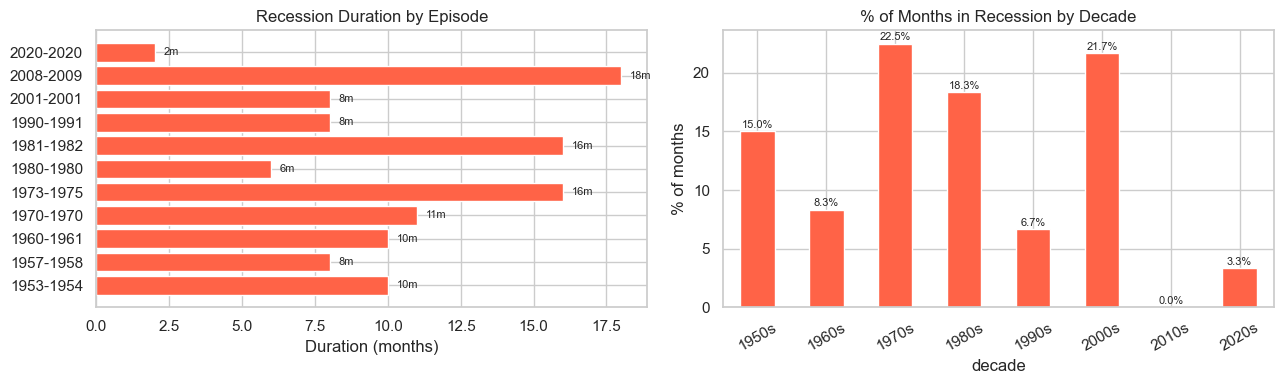

In [24]:
# Duration by episode + % of decade in recession
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels = episodes['start'].dt.year.astype(str) + '-' + episodes['end'].dt.year.astype(str)
axes[0].barh(labels, episodes['duration_months'], color='tomato', edgecolor='white')
axes[0].set_xlabel('Duration (months)')
axes[0].set_title('Recession Duration by Episode')
for i, v in enumerate(episodes['duration_months']):
    axes[0].text(v + 0.3, i, str(v) + 'm', va='center', fontsize=8)

usrec['decade'] = (usrec['year'] // 10 * 10).astype(str) + 's'
decade_pct = usrec.groupby('decade')['USREC'].mean() * 100
decade_pct.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('% of Months in Recession by Decade')
axes[1].set_ylabel('% of months')
axes[1].tick_params(axis='x', rotation=30)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

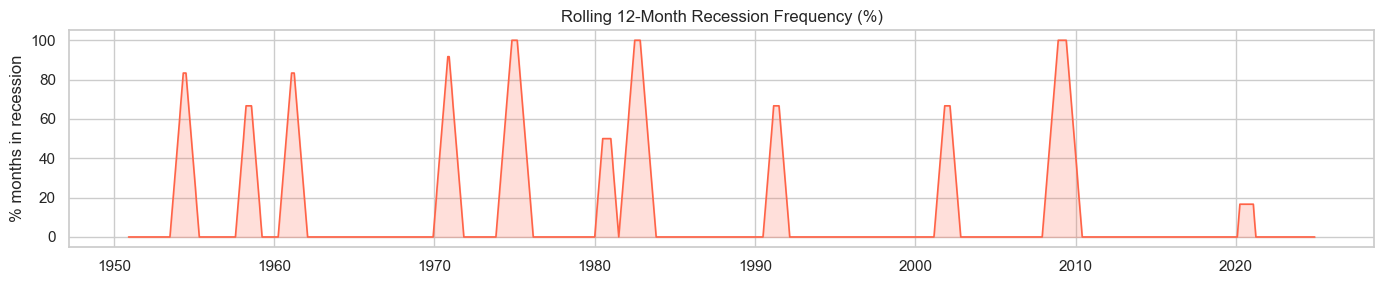

In [25]:
# Rolling 12-month recession rate
usrec['rec_12m'] = usrec['USREC'].rolling(12).mean() * 100
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(usrec['date'], usrec['rec_12m'], color='tomato', linewidth=1.2)
ax.fill_between(usrec['date'], usrec['rec_12m'], alpha=0.2, color='tomato')
ax.set_title('Rolling 12-Month Recession Frequency (%)')
ax.set_ylabel('% months in recession')
plt.tight_layout()
plt.show()

The charts show how long U.S. recessions lasted and how frequently they occurred across different decades.

The left chart (Recession Duration by Episode) displays the length of each recession since the 1950s in months. Some recessions were relatively short, such as the 2020 COVID-19 recession (2 months) and the 1980 recession (6 months). Others lasted much longer, including the 2008–2009 Global Financial Crisis (18 months), which was the longest in the period shown, and the 1973–1975 and 1981–1982 recessions (both about 16 months). Most recessions lasted between 8 and 11 months, showing that economic downturns typically persist for less than a year but can sometimes extend longer during major economic shocks.

The right chart (% of Months in Recession by Decade) shows how much of each decade the U.S. economy spent in recession. The 1970s (22.5%) and 2000s (21.7%) had the highest share of recession months, reflecting difficult economic periods marked by oil crises in the 1970s and the dot-com crash and financial crisis in the 2000s. The 1980s also experienced significant recession activity (18.3%), largely due to high inflation and aggressive interest rate policies. In contrast, the 2010s had no recession months, representing one of the longest economic expansions in modern history. The 2020s so far show a small percentage (3.3%), mainly due to the brief pandemic recession.

Overall, these charts illustrate that recessions vary widely in length and frequency across decades, and major economic shocks can cause longer downturns. Understanding these cycles is important for credit and financial analysis because loan defaults, delinquency rates, and financial stress tend to rise during recession periods.

## 6. Summary

In [26]:
print('=== CREDIT DATASET ===')
print(f'Loans        : {len(credit):,}')
print(f'Default rate : {credit["loan_status"].mean():.2%}')
print(f'Avg loan amt : ${credit["loan_amnt"].mean():,.0f}')
print(f'Avg int rate : {credit["loan_int_rate"].mean():.1f}%')
print()
print('=== USREC (1950-2024) ===')
print(f'Total months     : {len(usrec)}')
print(f'Recession months : {usrec["USREC"].sum()} ({usrec["USREC"].mean():.1%})')
print(f'Recession count  : {len(episodes)}')
print(f'Avg duration     : {episodes["duration_months"].mean():.1f} months')
print(f'Longest          : {episodes["duration_months"].max()} months')

=== CREDIT DATASET ===
Loans        : 32,576
Default rate : 21.82%
Avg loan amt : $9,589
Avg int rate : 11.0%

=== USREC (1950-2024) ===
Total months     : 900
Recession months : 113 (12.6%)
Recession count  : 11
Avg duration     : 10.3 months
Longest          : 18 months


Credit Dataset
The dataset contains 32,576 loans with an average loan amount of $9,589 at an 11% average interest rate. The 21.82% default rate is significantly elevated compared to real-world consumer loan charge-off rates of 2–5%, which confirms this is a synthetically generated dataset designed for classification modeling rather than a representative sample of actual lending portfolios. Within-dataset patterns remain analytically valid — grade ordering, intent-based risk differences, and feature correlations are internally consistent.

USREC (1950–2024)
Across 75 years and 900 monthly observations, the U.S. economy spent 113 months — roughly 12.6% of all time — in recession across 11 distinct episodes. The average recession lasted 10.3 months, with the longest running 18 months (the 2008–2009 Global Financial Crisis). This means expansions are the overwhelming norm, with recessions being relatively brief but consequential disruptions. The 12.6% historical frequency is a useful baseline: any credit risk model that ignores the economic cycle is implicitly assuming the economy is always in the 87.4% expansion state.

Why they matter together
Even without a direct join, these two datasets tell a coherent story. The credit dataset captures borrower-level risk factors — income, loan grade, employment, debt burden — while USREC captures the macro environment those borrowers would be operating in. A loan that looks acceptable in expansion conditions (87.4% of the time) can deteriorate sharply in the 12.6% of time spent in recession. The average 10-month recession duration means a typical 3–5 year loan will almost certainly overlap with at least one recession in its lifetime — making recession-era stress testing an essential complement to any model trained on this data.